<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Nikhil Prasad Fendre

Batch :CS1


Roll Number :CS15



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [2]:
# Task 2: Explore the Dataset

# 1. Display the shape of the dataset
print("Dataset Shape:")
print(df.shape)

# 2. Display the first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# 3. Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# 4. Check data types of all columns
print("\nData Types:")
print(df.dtypes)

# 5. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 6. Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 7. Check diagnosis class distribution
print("\nDiagnosis Class Distribution:")
print(df["diagnosis"].value_counts())

Dataset Shape:
(569, 33)

First 5 Rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Diagnosis Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis into numerical values
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Display the shapes
print("Feature Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)

# Display first 5 rows of X
print("\nFeature Matrix X:")
display(X.head())

# Display first 5 values of y
print("\nTarget Vector y:")
display(y.head())

Feature Matrix X Shape: (569, 30)
Target Vector y Shape: (569,)

Feature Matrix X:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Vector y:


,diagnosis
0,1
1,1
2,1
3,1
4,1


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# Task 4: Standardize Features

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize the feature matrix
X_scaled = scaler.fit_transform(X)

# Display the shape
print("Scaled Feature Matrix Shape:", X_scaled.shape)

# Display first 5 rows
print("\nFirst 5 Rows After Standardization:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Scaled Feature Matrix Shape: (569, 30)

First 5 Rows After Standardization:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# Task 5: Implement PCA (30D to 2D)

from sklearn.decomposition import PCA

# Create PCA object with 2 components
pca = PCA(n_components=2)

# Transform the standardized data into 2 principal components
X_pca = pca.fit_transform(X_scaled)

# Store PCA results in a DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("Original Number of Features:", X.shape[1])
print("Number of PCA Components:", X_pca.shape[1])

print("\nPCA Transformed Data:")
display(pca_df.head())

Original Number of Features: 30
Number of PCA Components: 2

PCA Transformed Data:


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [6]:
# Task 6: Analyze Explained Variance Ratio

# Get the explained variance ratio of PC1 and PC2
explained_variance = pca.explained_variance_ratio_

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

print("\nExplained Variance Percentage:")
print("PC1:", explained_variance[0] * 100, "%")
print("PC2:", explained_variance[1] * 100, "%")

print("\nCumulative Explained Variance:")
print("PC1 + PC2:", cumulative_variance[1] * 100, "%")

Explained Variance Ratio:
PC1: 0.44272025607526366
PC2: 0.18971182044033078

Explained Variance Percentage:
PC1: 44.272025607526366 %
PC2: 18.97118204403308 %

Cumulative Explained Variance:
PC1 + PC2: 63.243207651559445 %


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

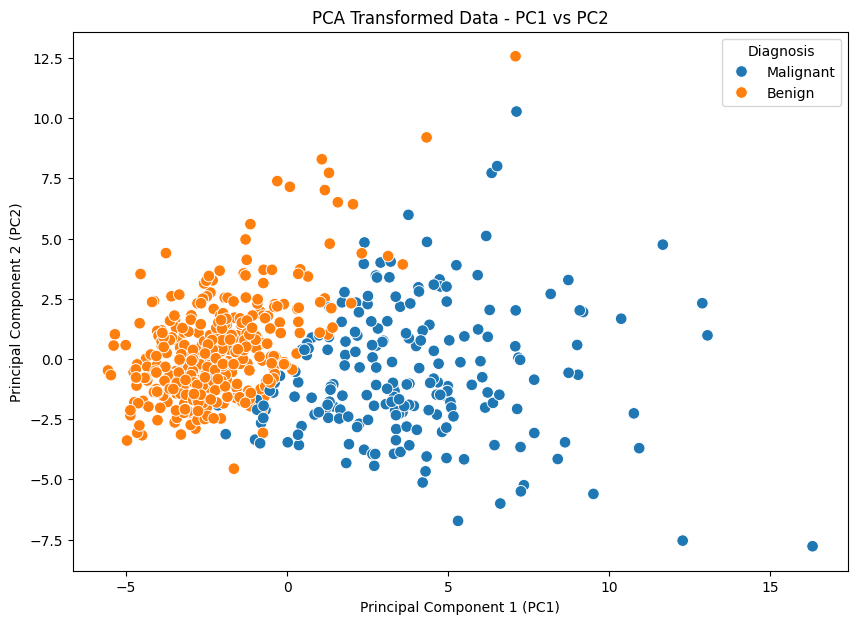

In [7]:
# Task 7: Visualize PCA Transformed Data

# Add diagnosis labels to PCA DataFrame
pca_df["Diagnosis"] = y.map({0: "Benign", 1: "Malignant"}).values

# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    s=70
)

plt.title("PCA Transformed Data - PC1 vs PC2")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Diagnosis")
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:
# Task 8: Train Classifier on Raw High-Dimensional Data

# Split the standardized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
logistic_raw = LogisticRegression(max_iter=1000)
logistic_raw.fit(X_train, y_train)

# Make predictions
y_pred_raw = logistic_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("--------------------------------------")
print("Accuracy:", accuracy_raw)

Logistic Regression using 30 Features
--------------------------------------
Accuracy: 0.9649122807017544


# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:
# Task 9: Train Classifier on PCA Transformed Data

# Split the PCA-transformed data into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
logistic_pca = LogisticRegression(max_iter=1000)
logistic_pca.fit(X_pca_train, y_pca_train)

# Make predictions
y_pred_pca = logistic_pca.predict(X_pca_test)

# Calculate accuracy
accuracy_pca = accuracy_score(y_pca_test, y_pred_pca)

print("Logistic Regression using 2 PCA Features")
print("----------------------------------------")
print("Accuracy:", accuracy_pca)

Logistic Regression using 2 PCA Features
----------------------------------------
Accuracy: 0.9385964912280702


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



Accuracy Comparison
-------------------
30 Features Accuracy: 0.9649122807017544
2 PCA Features Accuracy: 0.9385964912280702

Confusion Matrix - 30 Features:
[[71  1]
 [ 3 39]]

Confusion Matrix - 2 PCA Features:
[[71  1]
 [ 6 36]]

Classification Report - 30 Features:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Classification Report - 2 PCA Features:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



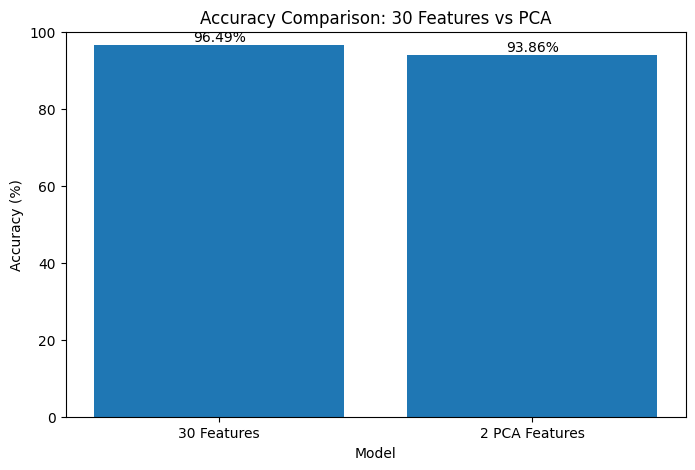

In [10]:
# Task 10: Compare Classification Performance

# Calculate confusion matrices
cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_pca = confusion_matrix(y_pca_test, y_pred_pca)

# Print accuracy comparison
print("Accuracy Comparison")
print("-------------------")
print("30 Features Accuracy:", accuracy_raw)
print("2 PCA Features Accuracy:", accuracy_pca)

# Print confusion matrices
print("\nConfusion Matrix - 30 Features:")
print(cm_raw)

print("\nConfusion Matrix - 2 PCA Features:")
print(cm_pca)

# Print classification reports
print("\nClassification Report - 30 Features:")
print(classification_report(y_test, y_pred_raw))

print("Classification Report - 2 PCA Features:")
print(classification_report(y_pca_test, y_pred_pca))


# Accuracy Comparison Graph
models = ["30 Features", "2 PCA Features"]
accuracies = [accuracy_raw * 100, accuracy_pca * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.title("Accuracy Comparison: 30 Features vs PCA")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Display accuracy values above bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.